# Unveiling the Android App Market — Google Play Store Analysis

## Project Overview

The Google Play Store contains applications from a wide range of categories such as
games, education, business, entertainment, health, finance, and productivity.

In this project, Google Play Store application data is analyzed to understand
category distribution, ratings, installs, application size, pricing patterns,
estimated revenue, and user sentiment.

The analysis uses two datasets: one containing application-level information and
another containing user reviews.

## Objectives

- Clean and preprocess real-world Google Play Store data.
- Analyze the distribution of applications across categories.
- Study application ratings and average ratings by category.
- Investigate the relationship between app size and number of installs.
- Compare free and paid applications.
- Analyze the pricing distribution of paid applications.
- Estimate potential revenue by category.
- Perform sentiment analysis on user reviews.
- Compare positive, negative, and neutral sentiment across categories.
- Create an interactive visualization using Plotly.
- Identify data-driven insights useful for developers planning a new application.

## Tools and Technologies

- Python
- Pandas
- NumPy
- Matplotlib
- Seaborn
- TextBlob
- Plotly
- Jupyter Notebook

## 1. Importing Libraries


In [1]:
!pip install vaderSentiment

Defaulting to user installation because normal site-packages is not writeable



[notice] A new release of pip is available: 23.2.1 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
!pip install plotly

Defaulting to user installation because normal site-packages is not writeable



[notice] A new release of pip is available: 23.2.1 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer
import plotly.express as px

import warnings
warnings.filterwarnings("ignore")

sns.set_style("whitegrid")

print("All libraries imported successfully!")

All libraries imported successfully!


## 2.Load Datasets

In [4]:
import os

os.chdir(r"C:\Users\Suyog\OneDrive\Desktop\Oasis")

print("Current folder:")
print(os.getcwd())

print("\nFiles available:")
print(os.listdir())

Current folder:
C:\Users\Suyog\OneDrive\Desktop\Oasis

Files available:
['googleplaystore.csv', 'googleplaystore_user_reviews.csv', 'retail_sales_dataset.csv', 'SnehaChorage_Task1.ipynb', 'SnehaChorage_Task2.ipynb', 'SnehaChorage_Task3.ipynb', 'train.csv']


In [5]:
apps = pd.read_csv("googleplaystore.csv")
reviews = pd.read_csv("googleplaystore_user_reviews.csv")

print("Apps dataset shape:", apps.shape)
print("Reviews dataset shape:", reviews.shape)

Apps dataset shape: (10841, 13)
Reviews dataset shape: (64295, 5)


## 3.Data Understanding

In [6]:
apps.head()

,App,Category,Rating,Reviews,Size,Installs,Type,Price,Content Rating,Genres,Last Updated,Current Ver,Android Ver
0,Photo Editor & Candy Camera & Grid & ScrapBook,ART_AND_DESIGN,4.1,159,19M,"10,000+",Free,0,Everyone,Art & Design,"January 7, 2018",1.0.0,4.0.3 and up
1,Coloring book moana,ART_AND_DESIGN,3.9,967,14M,"500,000+",Free,0,Everyone,Art & Design;Pretend Play,"January 15, 2018",2.0.0,4.0.3 and up
2,"U Launcher Lite – FREE Live Cool Themes, Hide ...",ART_AND_DESIGN,4.7,87510,8.7M,"5,000,000+",Free,0,Everyone,Art & Design,"August 1, 2018",1.2.4,4.0.3 and up
3,Sketch - Draw & Paint,ART_AND_DESIGN,4.5,215644,25M,"50,000,000+",Free,0,Teen,Art & Design,"June 8, 2018",Varies with device,4.2 and up
4,Pixel Draw - Number Art Coloring Book,ART_AND_DESIGN,4.3,967,2.8M,"100,000+",Free,0,Everyone,Art & Design;Creativity,"June 20, 2018",1.1,4.4 and up


In [7]:
reviews.head()

,App,Translated_Review,Sentiment,Sentiment_Polarity,Sentiment_Subjectivity
0,10 Best Foods for You,I like eat delicious food. That's I'm cooking ...,Positive,1.00,0.533333
1,10 Best Foods for You,This help eating healthy exercise regular basis,Positive,0.25,0.288462
2,10 Best Foods for You,NaN,NaN,NaN,NaN
3,10 Best Foods for You,Works great especially going grocery store,Positive,0.40,0.875000
4,10 Best Foods for You,Best idea us,Positive,1.00,0.300000


In [8]:
print("App dataset columns:")
print(apps.columns.tolist())

App dataset columns:
['App', 'Category', 'Rating', 'Reviews', 'Size', 'Installs', 'Type', 'Price', 'Content Rating', 'Genres', 'Last Updated', 'Current Ver', 'Android Ver']


In [9]:
print("Review dataset columns:")
print(reviews.columns.tolist())

Review dataset columns:
['App', 'Translated_Review', 'Sentiment', 'Sentiment_Polarity', 'Sentiment_Subjectivity']


In [10]:
print("APP DATASET")
apps.info()

APP DATASET
<class 'pandas.DataFrame'>
RangeIndex: 10841 entries, 0 to 10840
Data columns (total 13 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   App             10841 non-null  str    
 1   Category        10841 non-null  str    
 2   Rating          9367 non-null   float64
 3   Reviews         10841 non-null  str    
 4   Size            10841 non-null  str    
 5   Installs        10841 non-null  str    
 6   Type            10840 non-null  str    
 7   Price           10841 non-null  str    
 8   Content Rating  10840 non-null  str    
 9   Genres          10841 non-null  str    
 10  Last Updated    10841 non-null  str    
 11  Current Ver     10833 non-null  str    
 12  Android Ver     10838 non-null  str    
dtypes: float64(1), str(12)
memory usage: 1.1 MB


In [11]:
print("\nREVIEW DATASET")
reviews.info()


REVIEW DATASET
<class 'pandas.DataFrame'>
RangeIndex: 64295 entries, 0 to 64294
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   App                     64295 non-null  str    
 1   Translated_Review       37427 non-null  str    
 2   Sentiment               37432 non-null  str    
 3   Sentiment_Polarity      37432 non-null  float64
 4   Sentiment_Subjectivity  37432 non-null  float64
dtypes: float64(2), str(3)
memory usage: 2.5 MB


In [12]:
print("Missing values in Apps dataset:")
print(apps.isnull().sum())

Missing values in Apps dataset:
App                  0
Category             0
Rating            1474
Reviews              0
Size                 0
Installs             0
Type                 1
Price                0
Content Rating       1
Genres               0
Last Updated         0
Current Ver          8
Android Ver          3
dtype: int64


In [13]:
print("\nMissing values in Reviews dataset:")
print(reviews.isnull().sum())


Missing values in Reviews dataset:
App                           0
Translated_Review         26868
Sentiment                 26863
Sentiment_Polarity        26863
Sentiment_Subjectivity    26863
dtype: int64


In [14]:
print("Duplicate rows in Apps dataset:",
      apps.duplicated().sum())

print("Duplicate rows in Reviews dataset:",
      reviews.duplicated().sum())

Duplicate rows in Apps dataset: 483
Duplicate rows in Reviews dataset: 33616


In [15]:
print(
    "Duplicate app names:",
    apps["App"].duplicated().sum()
)

Duplicate app names: 1181


In [16]:
print(apps["Installs"].head(20).to_string(index=False))

    10,000+
   500,000+
 5,000,000+
50,000,000+
   100,000+
    50,000+
    50,000+
 1,000,000+
 1,000,000+
    10,000+
 1,000,000+
 1,000,000+
10,000,000+
   100,000+
   100,000+
     5,000+
   500,000+
    10,000+
 5,000,000+
10,000,000+


In [17]:
print(apps["Price"].head(20).to_string(index=False))

0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0


In [18]:
print(apps["Size"].head(20).to_string(index=False))

 19M
 14M
8.7M
 25M
2.8M
5.6M
 19M
 29M
 33M
3.1M
 28M
 12M
 20M
 21M
 37M
2.7M
5.5M
 17M
 39M
 31M


In [19]:
print(apps["Rating"].head(20).to_string(index=False))

4.1
3.9
4.7
4.5
4.3
4.4
3.8
4.1
4.4
4.7
4.4
4.4
4.2
4.6
4.4
3.2
4.7
4.5
4.3
4.6


In [20]:
print(apps["Reviews"].head(20).to_string(index=False))

   159
   967
 87510
215644
   967
   167
   178
 36815
 13791
   121
 13880
  8788
 44829
  4326
  1518
    55
  3632
    27
194216
224399


In [21]:
print("App dataset columns:")
print(apps.columns.tolist())

print("\nReview dataset columns:")
print(reviews.columns.tolist())

App dataset columns:
['App', 'Category', 'Rating', 'Reviews', 'Size', 'Installs', 'Type', 'Price', 'Content Rating', 'Genres', 'Last Updated', 'Current Ver', 'Android Ver']

Review dataset columns:
['App', 'Translated_Review', 'Sentiment', 'Sentiment_Polarity', 'Sentiment_Subjectivity']


In [22]:
apps.info()

<class 'pandas.DataFrame'>
RangeIndex: 10841 entries, 0 to 10840
Data columns (total 13 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   App             10841 non-null  str    
 1   Category        10841 non-null  str    
 2   Rating          9367 non-null   float64
 3   Reviews         10841 non-null  str    
 4   Size            10841 non-null  str    
 5   Installs        10841 non-null  str    
 6   Type            10840 non-null  str    
 7   Price           10841 non-null  str    
 8   Content Rating  10840 non-null  str    
 9   Genres          10841 non-null  str    
 10  Last Updated    10841 non-null  str    
 11  Current Ver     10833 non-null  str    
 12  Android Ver     10838 non-null  str    
dtypes: float64(1), str(12)
memory usage: 1.1 MB


In [23]:
reviews.info()

<class 'pandas.DataFrame'>
RangeIndex: 64295 entries, 0 to 64294
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   App                     64295 non-null  str    
 1   Translated_Review       37427 non-null  str    
 2   Sentiment               37432 non-null  str    
 3   Sentiment_Polarity      37432 non-null  float64
 4   Sentiment_Subjectivity  37432 non-null  float64
dtypes: float64(2), str(3)
memory usage: 2.5 MB


In [24]:
apps.describe()

,Rating
count,9367.000000
mean,4.193338
std,0.537431
min,1.000000
25%,4.000000
50%,4.300000
75%,4.500000
max,19.000000


In [25]:
reviews.describe()

,Sentiment_Polarity,Sentiment_Subjectivity
count,37432.000000,37432.000000
mean,0.182146,0.492704
std,0.351301,0.259949
min,-1.000000,0.000000
25%,0.000000,0.357143
50%,0.150000,0.514286
75%,0.400000,0.650000
max,1.000000,1.000000


## 4.Data Cleaning

In [26]:
apps_clean = apps.copy()
reviews_clean = reviews.copy()

print("Copies created successfully.")

Copies created successfully.


In [27]:
print("Duplicate app names before cleaning:",
      apps_clean["App"].duplicated().sum())

Duplicate app names before cleaning: 1181


In [28]:
apps_clean = apps_clean.drop_duplicates(
    subset="App",
    keep="first"
).copy()

In [29]:
print("Duplicate app names after cleaning:",
      apps_clean["App"].duplicated().sum())

Duplicate app names after cleaning: 0


In [30]:
apps_clean["Rating"] = pd.to_numeric(
    apps_clean["Rating"],
    errors="coerce"
)
print(apps_clean["Rating"].dtype)

float64


In [31]:
apps_clean.dropna(subset=["Rating"])

,App,Category,Rating,Reviews,Size,Installs,Type,Price,Content Rating,Genres,Last Updated,Current Ver,Android Ver
0,Photo Editor & Candy Camera & Grid & ScrapBook,ART_AND_DESIGN,4.1,159,19M,"10,000+",Free,0,Everyone,Art & Design,"January 7, 2018",1.0.0,4.0.3 and up
1,Coloring book moana,ART_AND_DESIGN,3.9,967,14M,"500,000+",Free,0,Everyone,Art & Design;Pretend Play,"January 15, 2018",2.0.0,4.0.3 and up
2,"U Launcher Lite – FREE Live Cool Themes, Hide ...",ART_AND_DESIGN,4.7,87510,8.7M,"5,000,000+",Free,0,Everyone,Art & Design,"August 1, 2018",1.2.4,4.0.3 and up
3,Sketch - Draw & Paint,ART_AND_DESIGN,4.5,215644,25M,"50,000,000+",Free,0,Teen,Art & Design,"June 8, 2018",Varies with device,4.2 and up
4,Pixel Draw - Number Art Coloring Book,ART_AND_DESIGN,4.3,967,2.8M,"100,000+",Free,0,Everyone,Art & Design;Creativity,"June 20, 2018",1.1,4.4 and up
...,...,...,...,...,...,...,...,...,...,...,...,...,...
10834,FR Calculator,FAMILY,4.0,7,2.6M,500+,Free,0,Everyone,Education,"June 18, 2017",1.0.0,4.1 and up
10836,Sya9a Maroc - FR,FAMILY,4.5,38,53M,"5,000+",Free,0,Everyone,Education,"July 25, 2017",1.48,4.1 and up
10837,Fr. Mike Schmitz Audio Teachings,FAMILY,5.0,4,3.6M,100+,Free,0,Everyone,Education,"July 6, 2018",1.0,4.1 and up
10839,The SCP Foundation DB fr nn5n,BOOKS_AND_REFERENCE,4.5,114,Varies with device,"1,000+",Free,0,Mature 17+,Books & Reference,"January 19, 2015",Varies with device,Varies with device


In [32]:
apps_clean["Reviews"] = pd.to_numeric(
    apps_clean["Reviews"],
    errors="coerce"
)
print(apps_clean["Reviews"].dtype)

float64


In [33]:
apps_clean["Installs"] = (
    apps_clean["Installs"]
    .astype(str)
    .str.replace(",", "", regex=False)
    .str.replace("+", "", regex=False)
)
apps_clean["Installs"] = pd.to_numeric(
    apps_clean["Installs"],
    errors="coerce"
)
print(apps_clean["Installs"].dtype)

float64


In [34]:
apps_clean["Price"] = (
    apps_clean["Price"]
    .astype(str)
    .str.replace("$", "", regex=False)
)

In [35]:
apps_clean["Price"] = pd.to_numeric(
    apps_clean["Price"],
    errors="coerce"
)

print("Price data type:", apps_clean["Price"].dtype)

Price data type: float64


In [36]:
print(apps_clean[["App", "Type", "Price"]].head(10))

                                                 App  Type  Price
0     Photo Editor & Candy Camera & Grid & ScrapBook  Free    0.0
1                                Coloring book moana  Free    0.0
2  U Launcher Lite – FREE Live Cool Themes, Hide ...  Free    0.0
3                              Sketch - Draw & Paint  Free    0.0
4              Pixel Draw - Number Art Coloring Book  Free    0.0
5                         Paper flowers instructions  Free    0.0
6            Smoke Effect Photo Maker - Smoke Editor  Free    0.0
7                                   Infinite Painter  Free    0.0
8                               Garden Coloring Book  Free    0.0
9                      Kids Paint Free - Drawing Fun  Free    0.0


In [37]:
def convert_size(size):
    if pd.isna(size):
        return np.nan

    size = str(size).strip()

    if size == "Varies with device":
        return np.nan

    if size.endswith("M"):
        return float(size[:-1])

    if size.endswith("k"):
        return float(size[:-1]) / 1024

    return np.nan

In [38]:
apps_clean["Size_MB"] = apps_clean["Size"].apply(convert_size)

In [39]:
print(apps_clean[["Size", "Size_MB"]].head(10))

   Size  Size_MB
0   19M     19.0
1   14M     14.0
2  8.7M      8.7
3   25M     25.0
4  2.8M      2.8
5  5.6M      5.6
6   19M     19.0
7   29M     29.0
8   33M     33.0
9  3.1M      3.1


In [40]:
print("Size_MB data type:", apps_clean["Size_MB"].dtype)

Size_MB data type: float64


In [41]:
print("Missing values in Apps dataset:")
print(apps_clean.isnull().sum())

Missing values in Apps dataset:
App                  0
Category             0
Rating            1463
Reviews              1
Size                 0
Installs             1
Type                 1
Price                1
Content Rating       1
Genres               0
Last Updated         0
Current Ver          8
Android Ver          3
Size_MB           1228
dtype: int64


In [42]:
apps_clean[
    apps_clean["Reviews"].isna() |
    apps_clean["Installs"].isna()
]

,App,Category,Rating,Reviews,Size,Installs,Type,Price,Content Rating,Genres,Last Updated,Current Ver,Android Ver,Size_MB
10472,Life Made WI-Fi Touchscreen Photo Frame,1.9,19.0,NaN,"1,000+",NaN,0,NaN,NaN,"February 11, 2018",1.0.19,4.0 and up,NaN,NaN


In [43]:
apps_clean = apps_clean.dropna(
    subset=["Reviews", "Installs"]
).copy()

print("Apps dataset shape after removing incomplete records:")
print(apps_clean.shape)

Apps dataset shape after removing incomplete records:
(9659, 14)


In [44]:
print("Missing Reviews:", apps_clean["Reviews"].isna().sum())
print("Missing Installs:", apps_clean["Installs"].isna().sum())

Missing Reviews: 0
Missing Installs: 0


In [45]:
reviews_clean = reviews_clean.dropna(
    subset=["Translated_Review"]
).copy()

print("Missing review text:",
      reviews_clean["Translated_Review"].isna().sum())

Missing review text: 0


In [46]:
reviews_clean = reviews_clean.drop_duplicates().copy()

print("Duplicate review rows:",
      reviews_clean.duplicated().sum())

Duplicate review rows: 0


In [47]:
print("Original Reviews shape:", reviews.shape)
print("Cleaned Reviews shape:", reviews_clean.shape)

Original Reviews shape: (64295, 5)
Cleaned Reviews shape: (29692, 5)


In [48]:
#compare sizes of dataset
print("Original Apps shape:", apps.shape)
print("Cleaned Apps shape:", apps_clean.shape)

print("\nOriginal Reviews shape:", reviews.shape)
print("Cleaned Reviews shape:", reviews_clean.shape)

Original Apps shape: (10841, 13)
Cleaned Apps shape: (9659, 14)

Original Reviews shape: (64295, 5)
Cleaned Reviews shape: (29692, 5)


In [49]:
#check duplicates
print("Duplicate app names:",
      apps_clean["App"].duplicated().sum())

print("Duplicate review rows:",
      reviews_clean.duplicated().sum())

Duplicate app names: 0
Duplicate review rows: 0


In [50]:
print(apps_clean[
    ["Rating", "Reviews", "Installs", "Price", "Size_MB"]
].dtypes)

Rating      float64
Reviews     float64
Installs    float64
Price       float64
Size_MB     float64
dtype: object


In [51]:
apps_clean[
    ["App", "Category", "Rating", "Reviews",
     "Size_MB", "Installs", "Type", "Price"]
].head()

,App,Category,Rating,Reviews,Size_MB,Installs,Type,Price
0,Photo Editor & Candy Camera & Grid & ScrapBook,ART_AND_DESIGN,4.1,159.0,19.0,10000.0,Free,0.0
1,Coloring book moana,ART_AND_DESIGN,3.9,967.0,14.0,500000.0,Free,0.0
2,"U Launcher Lite – FREE Live Cool Themes, Hide ...",ART_AND_DESIGN,4.7,87510.0,8.7,5000000.0,Free,0.0
3,Sketch - Draw & Paint,ART_AND_DESIGN,4.5,215644.0,25.0,50000000.0,Free,0.0
4,Pixel Draw - Number Art Coloring Book,ART_AND_DESIGN,4.3,967.0,2.8,100000.0,Free,0.0


In [52]:
reviews_clean[
    ["App", "Translated_Review"]
].head()

,App,Translated_Review
0,10 Best Foods for You,I like eat delicious food. That's I'm cooking ...
1,10 Best Foods for You,This help eating healthy exercise regular basis
3,10 Best Foods for You,Works great especially going grocery store
4,10 Best Foods for You,Best idea us
5,10 Best Foods for You,Best way


## 5. Category Analysis

In [53]:
print("Number of unique categories:",
      apps_clean["Category"].nunique())

print("\nCategories:")
print(apps_clean["Category"].unique())

Number of unique categories: 33

Categories:
<StringArray>
[     'ART_AND_DESIGN',   'AUTO_AND_VEHICLES',              'BEAUTY',
 'BOOKS_AND_REFERENCE',            'BUSINESS',              'COMICS',
       'COMMUNICATION',              'DATING',           'EDUCATION',
       'ENTERTAINMENT',              'EVENTS',             'FINANCE',
      'FOOD_AND_DRINK',  'HEALTH_AND_FITNESS',      'HOUSE_AND_HOME',
  'LIBRARIES_AND_DEMO',           'LIFESTYLE',                'GAME',
              'FAMILY',             'MEDICAL',              'SOCIAL',
            'SHOPPING',         'PHOTOGRAPHY',              'SPORTS',
    'TRAVEL_AND_LOCAL',               'TOOLS',     'PERSONALIZATION',
        'PRODUCTIVITY',           'PARENTING',             'WEATHER',
       'VIDEO_PLAYERS',  'NEWS_AND_MAGAZINES', 'MAPS_AND_NAVIGATION']
Length: 33, dtype: str


In [54]:
category_counts = apps_clean["Category"].value_counts()

print(category_counts)

Category
FAMILY                 1832
GAME                    959
TOOLS                   827
BUSINESS                420
MEDICAL                 395
PERSONALIZATION         376
PRODUCTIVITY            374
LIFESTYLE               369
FINANCE                 345
SPORTS                  325
COMMUNICATION           315
HEALTH_AND_FITNESS      288
PHOTOGRAPHY             281
NEWS_AND_MAGAZINES      254
SOCIAL                  239
BOOKS_AND_REFERENCE     222
TRAVEL_AND_LOCAL        219
SHOPPING                202
DATING                  171
VIDEO_PLAYERS           163
MAPS_AND_NAVIGATION     131
EDUCATION               119
FOOD_AND_DRINK          112
ENTERTAINMENT           102
AUTO_AND_VEHICLES        85
LIBRARIES_AND_DEMO       84
WEATHER                  79
HOUSE_AND_HOME           74
ART_AND_DESIGN           64
EVENTS                   64
PARENTING                60
COMICS                   56
BEAUTY                   53
Name: count, dtype: int64


In [55]:
category_table = category_counts.reset_index()

category_table.columns = ["Category", "App_Count"]

category_table

,Category,App_Count
0,FAMILY,1832
1,GAME,959
2,TOOLS,827
3,BUSINESS,420
4,MEDICAL,395
5,PERSONALIZATION,376
6,PRODUCTIVITY,374
7,LIFESTYLE,369
8,FINANCE,345
9,SPORTS,325


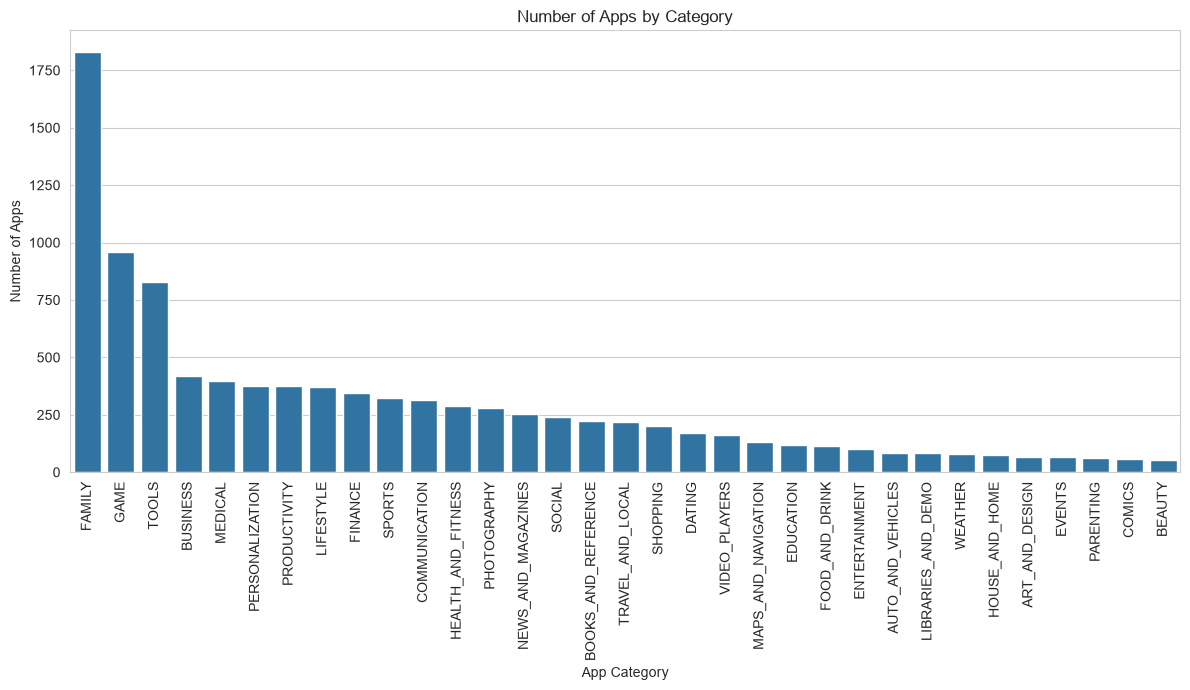

In [56]:
plt.figure(figsize=(12, 7))

sns.barplot(
    data=category_table,
    x="Category",
    y="App_Count"
)

plt.title("Number of Apps by Category")
plt.xlabel("App Category")
plt.ylabel("Number of Apps")
plt.xticks(rotation=90)

plt.tight_layout()
plt.show()

Observation:

The Family category has the highest number of apps in the cleaned dataset, with 1,832 apps. Game and Tools follow with 959 and 827 apps respectively. This indicates that these categories have a much larger representation of apps in the Google Play Store dataset compared with most other categories.

In [57]:
# Percentage Distribution
category_table["Percentage"] = (
    category_table["App_Count"] /
    category_table["App_Count"].sum()
) * 100

category_table.head(10)

,Category,App_Count,Percentage
0,FAMILY,1832,18.966767
1,GAME,959,9.928564
2,TOOLS,827,8.561963
3,BUSINESS,420,4.348276
4,MEDICAL,395,4.089450
5,PERSONALIZATION,376,3.892743
6,PRODUCTIVITY,374,3.872036
7,LIFESTYLE,369,3.820271
8,FINANCE,345,3.571798
9,SPORTS,325,3.364738


In [58]:
print(
    category_table[
        ["Category", "App_Count", "Percentage"]
    ].head(10)
)

          Category  App_Count  Percentage
0           FAMILY       1832   18.966767
1             GAME        959    9.928564
2            TOOLS        827    8.561963
3         BUSINESS        420    4.348276
4          MEDICAL        395    4.089450
5  PERSONALIZATION        376    3.892743
6     PRODUCTIVITY        374    3.872036
7        LIFESTYLE        369    3.820271
8          FINANCE        345    3.571798
9           SPORTS        325    3.364738


In [59]:
top_categories = category_table.head(5)

print("Top 5 categories by number of apps:")
print(top_categories[["Category", "App_Count", "Percentage"]])

Top 5 categories by number of apps:
   Category  App_Count  Percentage
0    FAMILY       1832   18.966767
1      GAME        959    9.928564
2     TOOLS        827    8.561963
3  BUSINESS        420    4.348276
4   MEDICAL        395    4.089450


Observation:

The Family category has the highest number of apps in the cleaned dataset, with 1,832 apps. Game and Tools follow with 959 and 827 apps respectively. These categories have a larger representation of apps in the dataset compared with most other categories.

The number of apps is used here as an indicator of category representation. A higher app count does not necessarily mean that the category has greater commercial competition or market saturation.

## 6. Rating Analysis

In [60]:
print("Rating statistics:")
print(apps_clean["Rating"].describe())

Rating statistics:
count    8196.000000
mean        4.173243
std         0.536625
min         1.000000
25%         4.000000
50%         4.300000
75%         4.500000
max         5.000000
Name: Rating, dtype: float64


In [61]:
print("Number of missing ratings:",
      apps_clean["Rating"].isna().sum())

Number of missing ratings: 1463


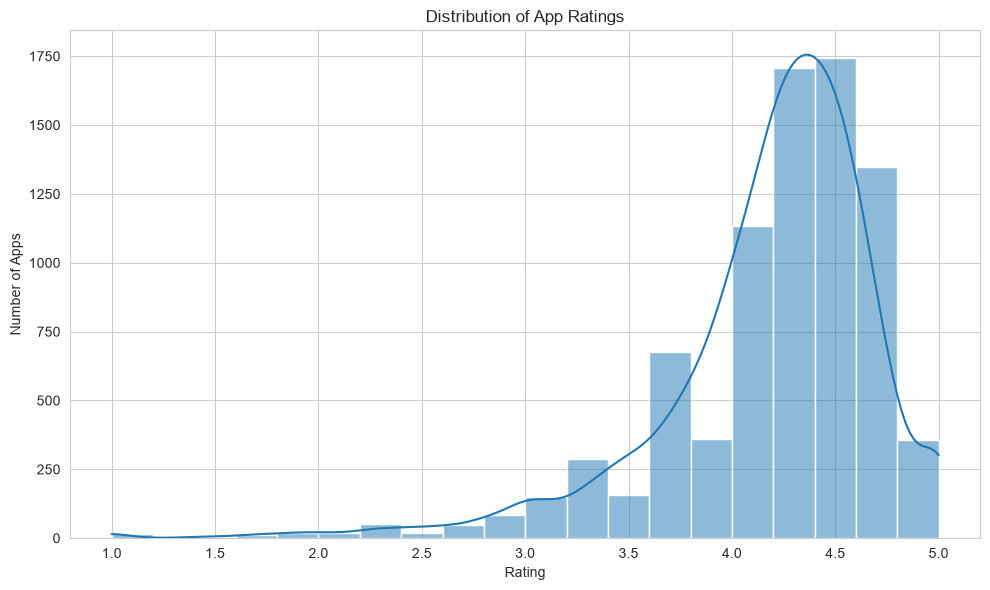

In [62]:
plt.figure(figsize=(10, 6))

sns.histplot(
    apps_clean["Rating"].dropna(),
    bins=20,
    kde=True
)

plt.title("Distribution of App Ratings")
plt.xlabel("Rating")
plt.ylabel("Number of Apps")

plt.tight_layout()
plt.show()

Observation: The distribution is concentrated toward the higher rating range. Most rated apps have ratings between approximately 4.0 and 4.8, while relatively few apps have ratings below 3.0. The average rating of the rated apps is 4.17.

In [63]:
category_ratings = (
    apps_clean.groupby("Category")["Rating"]
    .mean()
    .sort_values(ascending=False)
    .reset_index()
)

category_ratings.columns = ["Category", "Average_Rating"]

category_ratings

,Category,Average_Rating
0,EVENTS,4.435556
1,EDUCATION,4.364407
2,ART_AND_DESIGN,4.357377
3,BOOKS_AND_REFERENCE,4.344970
4,PERSONALIZATION,4.332215
5,PARENTING,4.300000
6,BEAUTY,4.278571
7,GAME,4.247368
8,SOCIAL,4.247291
9,WEATHER,4.243056


In [64]:
print("Top 10 categories by average rating:")
print(category_ratings.head(10))

Top 10 categories by average rating:
              Category  Average_Rating
0               EVENTS        4.435556
1            EDUCATION        4.364407
2       ART_AND_DESIGN        4.357377
3  BOOKS_AND_REFERENCE        4.344970
4      PERSONALIZATION        4.332215
5            PARENTING        4.300000
6               BEAUTY        4.278571
7                 GAME        4.247368
8               SOCIAL        4.247291
9              WEATHER        4.243056


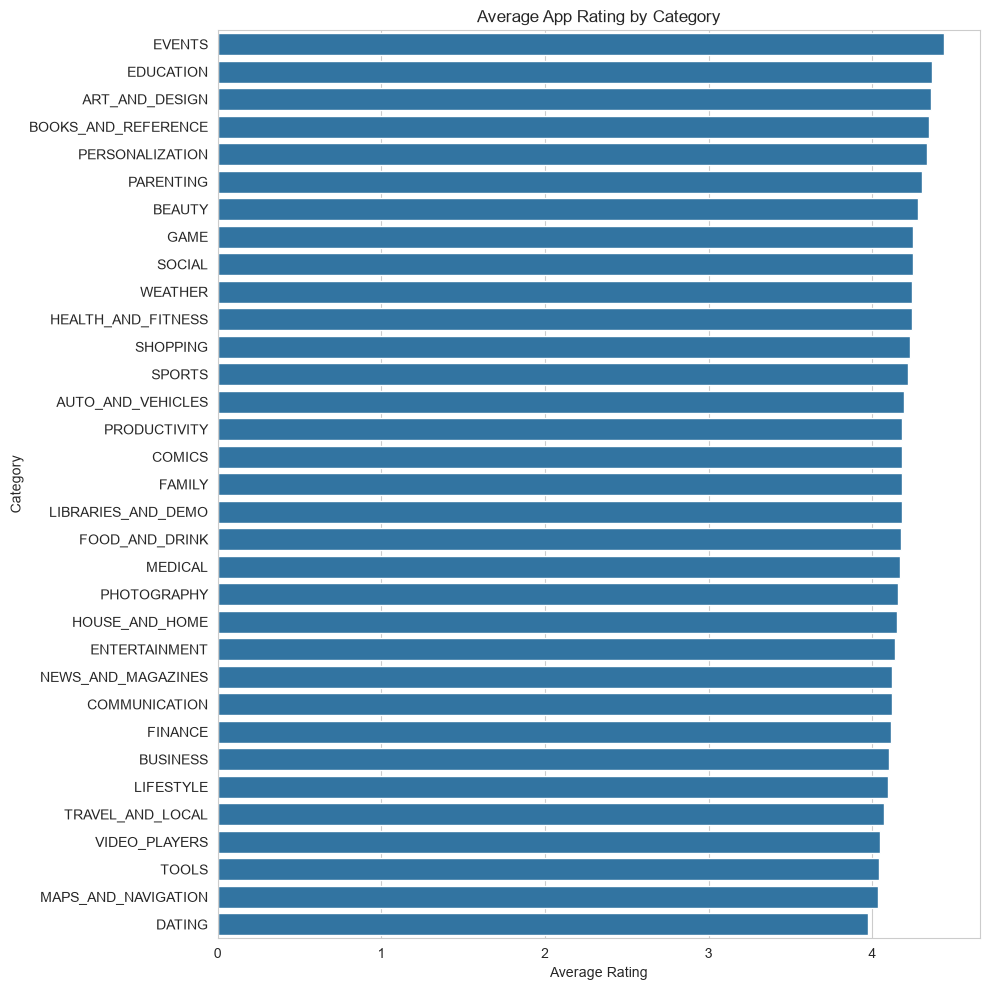

In [65]:
plt.figure(figsize=(10, 10))

sns.barplot(
    data=category_ratings,
    x="Average_Rating",
    y="Category"
)

plt.title("Average App Rating by Category")
plt.xlabel("Average Rating")
plt.ylabel("Category")

plt.tight_layout()
plt.show()

Observation:

The average ratings vary across the 33 app categories, but most categories have average ratings above 4.0. Events has the highest average rating at approximately 4.44, followed by Education at 4.36 and Art & Design at 4.36. The overall average rating of the rated apps is 4.17.

## 7.Size and Installs Analysis

In [66]:
size_installs = apps_clean.dropna(
    subset=["Size_MB", "Installs"]
).copy()

print("Rows available for Size vs Installs analysis:",
      len(size_installs))

Rows available for Size vs Installs analysis: 8432


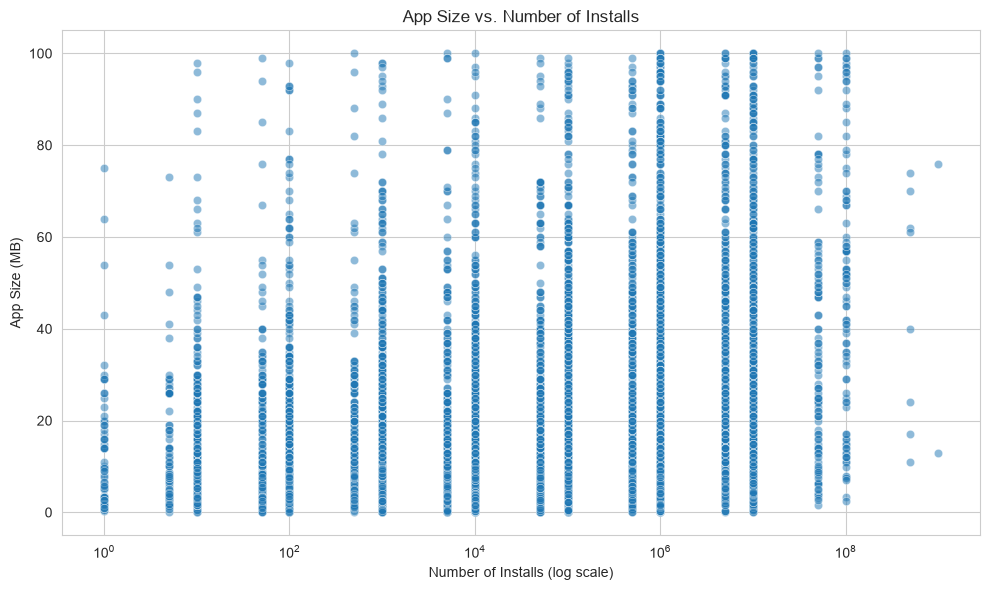

In [67]:
plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=size_installs,
    x="Installs",
    y="Size_MB",
    alpha=0.5
)

plt.xscale("log")

plt.title("App Size vs. Number of Installs")
plt.xlabel("Number of Installs (log scale)")
plt.ylabel("App Size (MB)")

plt.tight_layout()
plt.show()

In [68]:
size_install_corr = size_installs["Size_MB"].corr(
    size_installs["Installs"]
)

print("Correlation between App Size and Installs:",
      round(size_install_corr, 4))

Correlation between App Size and Installs: 0.1343


Observation:

The correlation between app size and number of installs is 0.1343, indicating a weak positive linear relationship between the two variables. This suggests that app size has only a limited linear association with the number of installs in this dataset. Therefore, larger app size does not necessarily correspond to a higher number of installs.

## 8.Pricing Analysis

In [69]:
## free vs paid apps
print("App Type distribution:")
print(apps_clean["Type"].value_counts())

App Type distribution:
Type
Free    8902
Paid     756
Name: count, dtype: int64


In [70]:
print("\nPercentage distribution:")
print(
    apps_clean["Type"].value_counts(normalize=True).mul(100).round(2)
)


Percentage distribution:
Type
Free    92.17
Paid     7.83
Name: proportion, dtype: float64


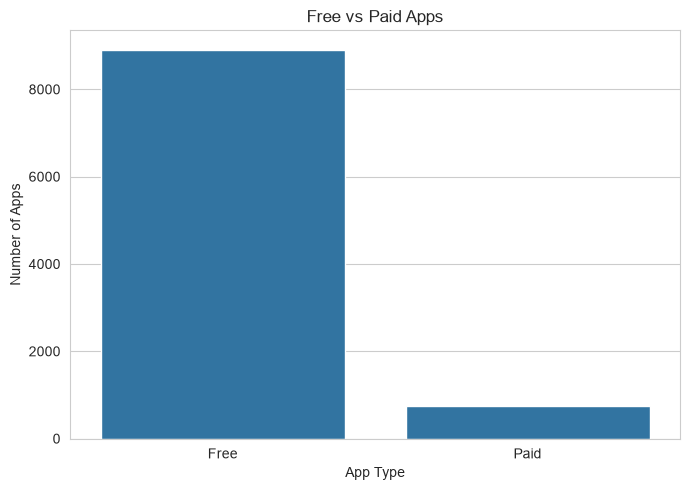

In [71]:
#chart
type_counts = apps_clean["Type"].value_counts()

plt.figure(figsize=(7, 5))

sns.barplot(
    x=type_counts.index,
    y=type_counts.values
)

plt.title("Free vs Paid Apps")
plt.xlabel("App Type")
plt.ylabel("Number of Apps")

plt.tight_layout()
plt.show()

In [72]:
#prices of paid apps
paid_apps = apps_clean[
    apps_clean["Type"] == "Paid"
].copy()

print("Number of paid apps:", len(paid_apps))

Number of paid apps: 756


In [73]:
print("Price statistics for paid apps:")
print(paid_apps["Price"].describe())

Price statistics for paid apps:
count    756.000000
mean      14.045146
std       58.743615
min        0.990000
25%        1.490000
50%        2.990000
75%        4.990000
max      400.000000
Name: Price, dtype: float64


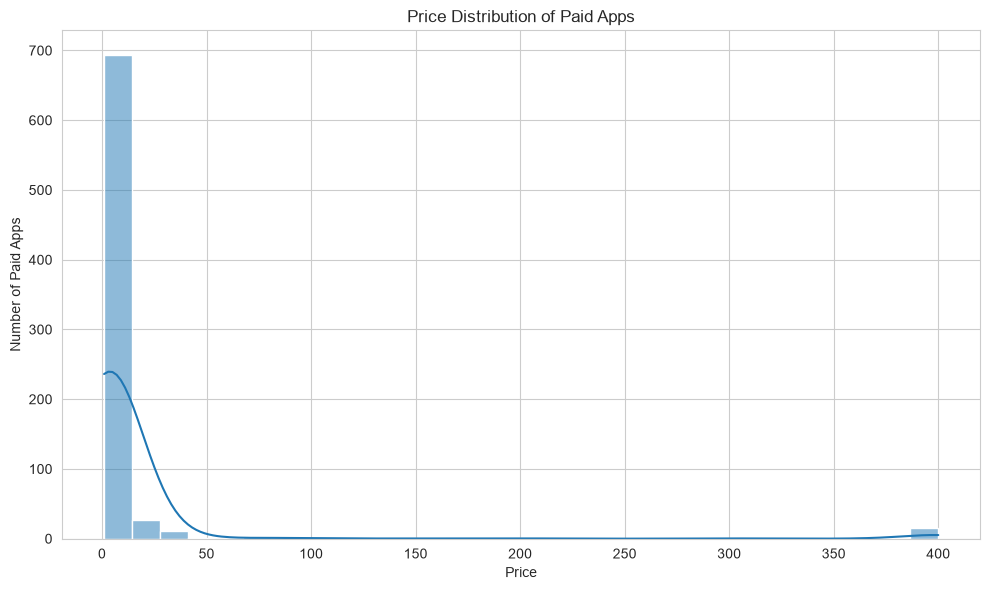

In [74]:
#price distribution chart
plt.figure(figsize=(10, 6))

sns.histplot(
    paid_apps["Price"],
    bins=30,
    kde=True
)

plt.title("Price Distribution of Paid Apps")
plt.xlabel("Price")
plt.ylabel("Number of Paid Apps")

plt.tight_layout()
plt.show()

In [75]:
#Revenue Estimate by Category
paid_apps["Estimated_Revenue"] = (
    paid_apps["Price"] * paid_apps["Installs"]
)

print(
    paid_apps[
        ["App", "Category", "Price", "Installs", "Estimated_Revenue"]
    ].head(10)
)

                                                   App       Category  Price  \
234      TurboScan: scan documents and receipts in PDF       BUSINESS   4.99   
235                     Tiny Scanner Pro: PDF Doc Scan       BUSINESS   4.99   
427                                 Puffin Browser Pro  COMMUNICATION   3.99   
476                          Moco+ - Chat, Meet People         DATING   3.99   
477                                         Calculator         DATING   6.99   
478                                  Truth or Dare Pro         DATING   1.49   
479    Private Dating, Hide App- Blue for PrivacyHider         DATING   2.99   
480                               Ad Blocker for SayHi         DATING   3.99   
481  AMBW Dating App: Asian Men Black Women Interra...         DATING   7.99   
851                                Sago Mini Hat Maker      EDUCATION   3.99   

     Installs  Estimated_Revenue  
234  100000.0           499000.0  
235  100000.0           499000.0  
427  100000.0 

In [76]:
revenue_by_category = (
    paid_apps.groupby("Category")["Estimated_Revenue"]
    .sum()
    .sort_values(ascending=False)
    .reset_index()
)

revenue_by_category.columns = [
    "Category",
    "Estimated_Revenue"
]

revenue_by_category.head(10)

,Category,Estimated_Revenue
0,FAMILY,1.136798e+08
1,LIFESTYLE,5.758394e+07
2,GAME,4.068864e+07
3,FINANCE,2.572668e+07
4,PHOTOGRAPHY,8.547768e+06
5,PERSONALIZATION,6.796948e+06
6,MEDICAL,5.957536e+06
7,TOOLS,5.464821e+06
8,SPORTS,4.706212e+06
9,PRODUCTIVITY,4.313375e+06


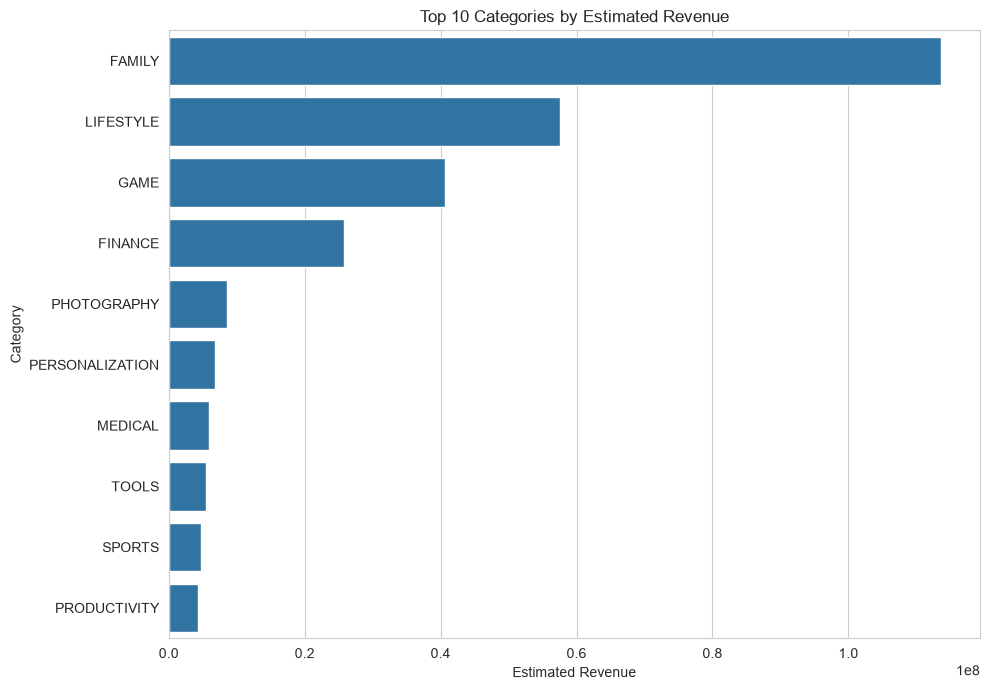

In [77]:
plt.figure(figsize=(10, 7))

sns.barplot(
    data=revenue_by_category.head(10),
    x="Estimated_Revenue",
    y="Category"
)

plt.title("Top 10 Categories by Estimated Revenue")
plt.xlabel("Estimated Revenue")
plt.ylabel("Category")

plt.tight_layout()
plt.show()

In [78]:
print("Top 10 categories by estimated revenue:")
print(revenue_by_category.head(10))

Top 10 categories by estimated revenue:
          Category  Estimated_Revenue
0           FAMILY       1.136798e+08
1        LIFESTYLE       5.758394e+07
2             GAME       4.068864e+07
3          FINANCE       2.572668e+07
4      PHOTOGRAPHY       8.547768e+06
5  PERSONALIZATION       6.796948e+06
6          MEDICAL       5.957536e+06
7            TOOLS       5.464821e+06
8           SPORTS       4.706212e+06
9     PRODUCTIVITY       4.313375e+06


Observation:

The dataset contains 8,902 free apps (92.17%) and 756 paid apps (7.83%), showing that free apps make up most of the dataset. The price distribution of paid apps is strongly right-skewed, with most paid apps having relatively low prices and a small number having much higher prices.

Using Price × Installs as an estimated revenue measure, the Family category has the highest estimated revenue, followed by Lifestyle, Game, and Finance. These values should be treated as approximate because the install counts are rounded in the original dataset.

## 9.Sentiment Analysis

In [79]:
#Initialize VADER
analyzer = SentimentIntensityAnalyzer()

print("VADER sentiment analyzer initialized successfully.")

VADER sentiment analyzer initialized successfully.


In [80]:
sample_reviews = reviews_clean["Translated_Review"].head(5)

for review in sample_reviews:
    score = analyzer.polarity_scores(review)
    
    print("Review:", review)
    print("VADER scores:", score)
    print("-" * 80)

Review: I like eat delicious food. That's I'm cooking food myself, case "10 Best Foods" helps lot, also "Best Before (Shelf Life)"
VADER scores: {'neg': 0.0, 'neu': 0.482, 'pos': 0.518, 'compound': 0.9531}
--------------------------------------------------------------------------------
Review: This help eating healthy exercise regular basis
VADER scores: {'neg': 0.0, 'neu': 0.481, 'pos': 0.519, 'compound': 0.6597}
--------------------------------------------------------------------------------
Review: Works great especially going grocery store
VADER scores: {'neg': 0.0, 'neu': 0.549, 'pos': 0.451, 'compound': 0.6249}
--------------------------------------------------------------------------------
Review: Best idea us
VADER scores: {'neg': 0.0, 'neu': 0.323, 'pos': 0.677, 'compound': 0.6369}
--------------------------------------------------------------------------------
Review: Best way
VADER scores: {'neg': 0.0, 'neu': 0.192, 'pos': 0.808, 'compound': 0.6369}
-------------------------

In [81]:
def get_vader_score(text):
    return analyzer.polarity_scores(text)["compound"]

In [82]:
reviews_clean["VADER_Compound"] = (
    reviews_clean["Translated_Review"].apply(get_vader_score)
)

print(reviews_clean[
    ["Translated_Review", "VADER_Compound"]
].head())

                                   Translated_Review  VADER_Compound
0  I like eat delicious food. That's I'm cooking ...          0.9531
1    This help eating healthy exercise regular basis          0.6597
3         Works great especially going grocery store          0.6249
4                                       Best idea us          0.6369
5                                           Best way          0.6369


In [83]:
def classify_sentiment(score):
    if score >= 0.05:
        return "Positive"
    elif score <= -0.05:
        return "Negative"
    else:
        return "Neutral"

In [84]:
reviews_clean["VADER_Sentiment"] = (
    reviews_clean["VADER_Compound"].apply(classify_sentiment)
)

In [85]:
print(reviews_clean[
    ["Translated_Review", "VADER_Compound", "VADER_Sentiment"]
].head(10))

                                    Translated_Review  VADER_Compound  \
0   I like eat delicious food. That's I'm cooking ...          0.9531   
1     This help eating healthy exercise regular basis          0.6597   
3          Works great especially going grocery store          0.6249   
4                                        Best idea us          0.6369   
5                                            Best way          0.6369   
6                                             Amazing          0.5859   
8                                Looking forward app,          0.0000   
9               It helpful site ! It help foods get !          0.7256   
10                                          good you.          0.4404   
11  Useful information The amount spelling errors ...          0.4404   

   VADER_Sentiment  
0         Positive  
1         Positive  
3         Positive  
4         Positive  
5         Positive  
6         Positive  
8          Neutral  
9         Positive  
10     

In [86]:
print("VADER Sentiment Distribution:")
print(reviews_clean["VADER_Sentiment"].value_counts())

VADER Sentiment Distribution:
VADER_Sentiment
Positive    20195
Negative     5867
Neutral      3630
Name: count, dtype: int64


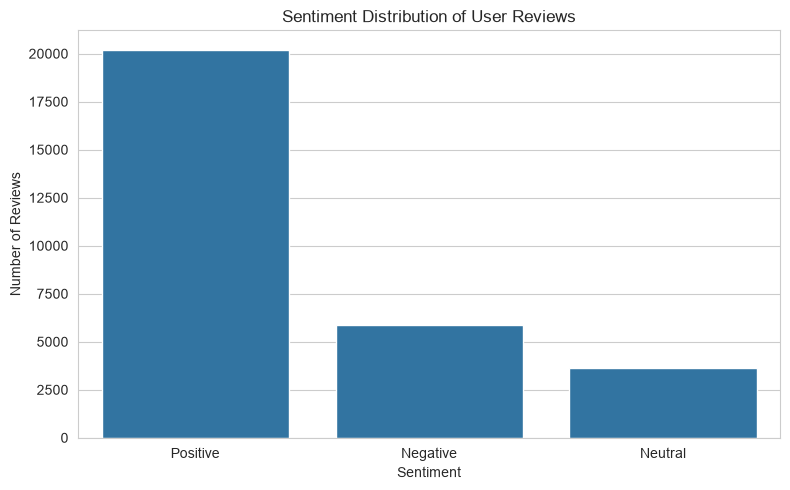

In [87]:
#chart
sentiment_counts = reviews_clean["VADER_Sentiment"].value_counts()

plt.figure(figsize=(8, 5))

sns.barplot(
    x=sentiment_counts.index,
    y=sentiment_counts.values
)

plt.title("Sentiment Distribution of User Reviews")
plt.xlabel("Sentiment")
plt.ylabel("Number of Reviews")

plt.tight_layout()
plt.show()

In [88]:
sentiment_percentage = (
    reviews_clean["VADER_Sentiment"]
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
)

print("Sentiment percentage distribution:")
print(sentiment_percentage)

Sentiment percentage distribution:
VADER_Sentiment
Positive    68.01
Negative    19.76
Neutral     12.23
Name: proportion, dtype: float64


In [89]:
reviews_with_category = reviews_clean.merge(
    apps_clean[["App", "Category"]],
    on="App",
    how="left"
)

print("Reviews with category information:")
print(reviews_with_category.shape)

print("\nMissing categories:")
print(reviews_with_category["Category"].isna().sum())

Reviews with category information:
(29692, 8)

Missing categories:
1442


In [90]:
print(
    reviews_with_category[
        ["App", "Category", "VADER_Sentiment", "VADER_Compound"]
    ].head(10)
)

                     App            Category VADER_Sentiment  VADER_Compound
0  10 Best Foods for You  HEALTH_AND_FITNESS        Positive          0.9531
1  10 Best Foods for You  HEALTH_AND_FITNESS        Positive          0.6597
2  10 Best Foods for You  HEALTH_AND_FITNESS        Positive          0.6249
3  10 Best Foods for You  HEALTH_AND_FITNESS        Positive          0.6369
4  10 Best Foods for You  HEALTH_AND_FITNESS        Positive          0.6369
5  10 Best Foods for You  HEALTH_AND_FITNESS        Positive          0.5859
6  10 Best Foods for You  HEALTH_AND_FITNESS         Neutral          0.0000
7  10 Best Foods for You  HEALTH_AND_FITNESS        Positive          0.7256
8  10 Best Foods for You  HEALTH_AND_FITNESS        Positive          0.4404
9  10 Best Foods for You  HEALTH_AND_FITNESS        Positive          0.4404


In [91]:
reviews_category_clean = reviews_with_category.dropna(
    subset=["Category"]
).copy()

print("Reviews available for category sentiment analysis:",
      len(reviews_category_clean))

print("Missing categories:",
      reviews_category_clean["Category"].isna().sum())

Reviews available for category sentiment analysis: 28250
Missing categories: 0


In [92]:
sentiment_by_category = pd.crosstab(
    reviews_category_clean["Category"],
    reviews_category_clean["VADER_Sentiment"],
    normalize="index"
) * 100

sentiment_by_category = sentiment_by_category.round(2)

sentiment_by_category.head()

VADER_Sentiment,Negative,Neutral,Positive
Category,,,
ART_AND_DESIGN,13.28,11.86,74.86
AUTO_AND_VEHICLES,4.95,12.72,82.33
BEAUTY,20.19,19.56,60.25
BOOKS_AND_REFERENCE,16.05,11.51,72.45
BUSINESS,16.89,19.79,63.32


In [93]:
top_positive_categories = (
    sentiment_by_category
    .sort_values("Positive", ascending=False)
)

print("Top 10 categories by positive sentiment:")
print(
    top_positive_categories[["Positive"]].head(10)
)

Top 10 categories by positive sentiment:
VADER_Sentiment     Positive
Category                    
COMICS                 86.67
AUTO_AND_VEHICLES      82.33
EVENTS                 80.13
EDUCATION              78.73
HEALTH_AND_FITNESS     78.47
ART_AND_DESIGN         74.86
FOOD_AND_DRINK         73.76
PARENTING              73.44
GAME                   72.97
FAMILY                 72.86


In [94]:
top_negative_categories = (
    sentiment_by_category
    .sort_values("Negative", ascending=False)
)

print("Top 10 categories by negative sentiment:")
print(
    top_negative_categories[["Negative"]].head(10)
)

Top 10 categories by negative sentiment:
VADER_Sentiment     Negative
Category                    
VIDEO_PLAYERS          31.90
SOCIAL                 31.47
ENTERTAINMENT          26.84
NEWS_AND_MAGAZINES     25.24
COMMUNICATION          25.15
FINANCE                24.18
DATING                 22.26
SPORTS                 22.04
TRAVEL_AND_LOCAL       21.79
SHOPPING               21.42


In [95]:
#sentiment by category chart 
top_positive = (
    sentiment_by_category
    .sort_values("Positive", ascending=False)
    .head(10)
)

top_negative = (
    sentiment_by_category
    .sort_values("Negative", ascending=False)
    .head(10)
)

In [96]:
print("Top 10 categories by positive sentiment:")
print(top_positive)

print("\nTop 10 categories by negative sentiment:")
print(top_negative)

Top 10 categories by positive sentiment:
VADER_Sentiment     Negative  Neutral  Positive
Category                                       
COMICS                  2.22    11.11     86.67
AUTO_AND_VEHICLES       4.95    12.72     82.33
EVENTS                 12.18     7.69     80.13
EDUCATION              10.40    10.87     78.73
HEALTH_AND_FITNESS     13.63     7.90     78.47
ART_AND_DESIGN         13.28    11.86     74.86
FOOD_AND_DRINK         15.27    10.98     73.76
PARENTING              10.55    16.02     73.44
GAME                   21.04     5.99     72.97
FAMILY                 16.98    10.16     72.86

Top 10 categories by negative sentiment:
VADER_Sentiment     Negative  Neutral  Positive
Category                                       
VIDEO_PLAYERS          31.90    11.35     56.75
SOCIAL                 31.47    13.46     55.07
ENTERTAINMENT          26.84    14.39     58.77
NEWS_AND_MAGAZINES     25.24    17.19     57.57
COMMUNICATION          25.15    12.87     61.99
FINAN

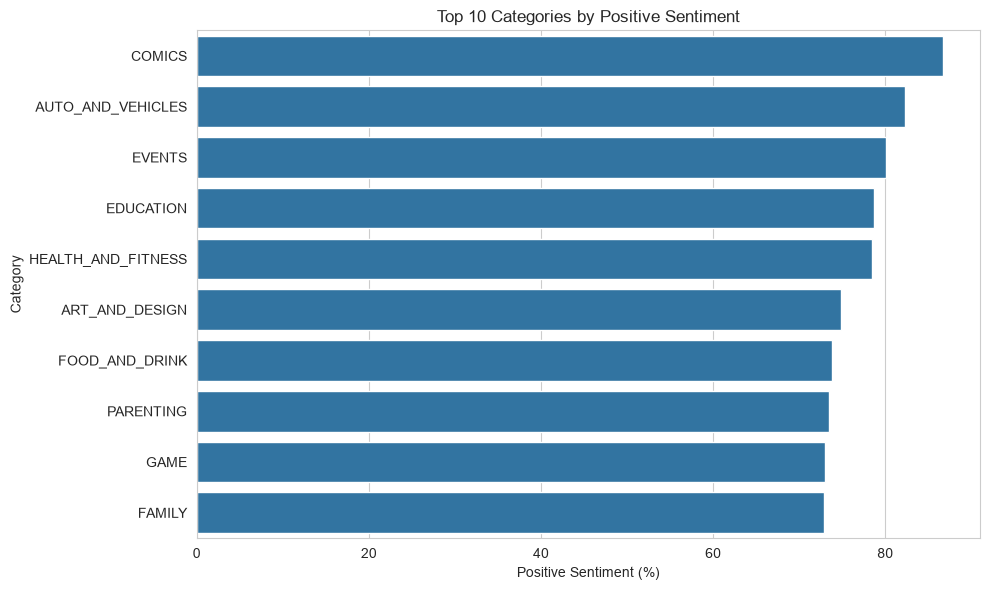

In [97]:
plt.figure(figsize=(10, 6))

sns.barplot(
    x=top_positive["Positive"],
    y=top_positive.index
)

plt.title("Top 10 Categories by Positive Sentiment")
plt.xlabel("Positive Sentiment (%)")
plt.ylabel("Category")

plt.tight_layout()
plt.show()

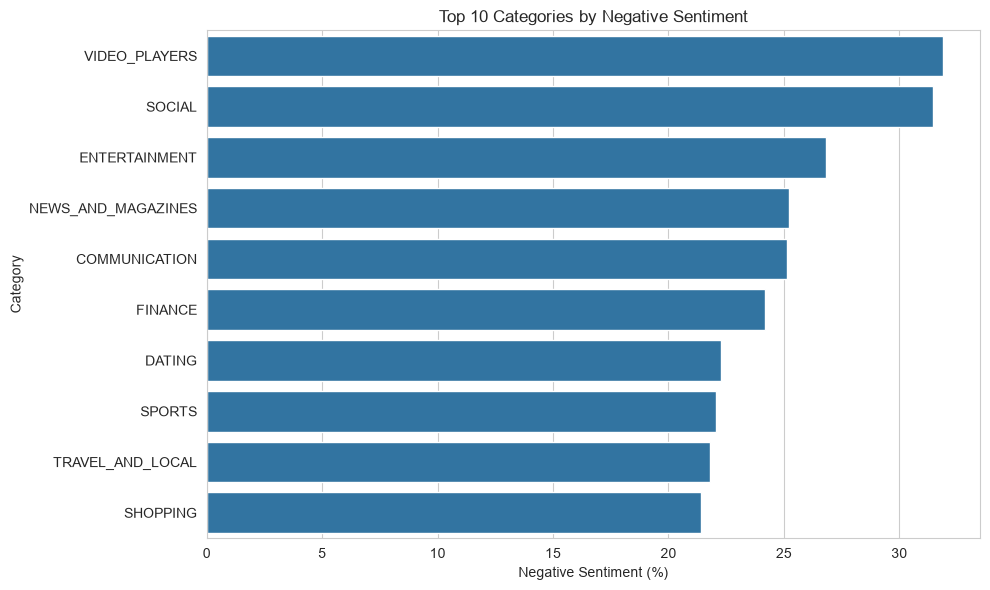

In [98]:
plt.figure(figsize=(10, 6))

sns.barplot(
    x=top_negative["Negative"],
    y=top_negative.index
)

plt.title("Top 10 Categories by Negative Sentiment")
plt.xlabel("Negative Sentiment (%)")
plt.ylabel("Category")

plt.tight_layout()
plt.show()

Observation: The sentiment analysis shows that positive reviews form the largest share of the cleaned review dataset, accounting for 68.01% of reviews. At the category level, Comics has the highest positive sentiment share at 86.67%, followed by Auto and Vehicles at 82.33%. Video Players has the highest negative sentiment share at 31.90%, followed by Social at 31.47%. These results show that sentiment varies across app categories.

## 10.Interactive Visualization using Plotly

In [99]:
!pip install plotly

Defaulting to user installation because normal site-packages is not writeable



[notice] A new release of pip is available: 23.2.1 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [100]:
print("apps_clean" in globals())
print("reviews_clean" in globals())

True
True


In [101]:
plotly_rating_data = (
    apps_clean.groupby("Category")["Rating"]
    .mean()
    .reset_index()
)

plotly_rating_data["Rating"] = (
    plotly_rating_data["Rating"].round(2)
)

print(plotly_rating_data.head())

              Category  Rating
0       ART_AND_DESIGN    4.36
1    AUTO_AND_VEHICLES    4.19
2               BEAUTY    4.28
3  BOOKS_AND_REFERENCE    4.34
4             BUSINESS    4.10


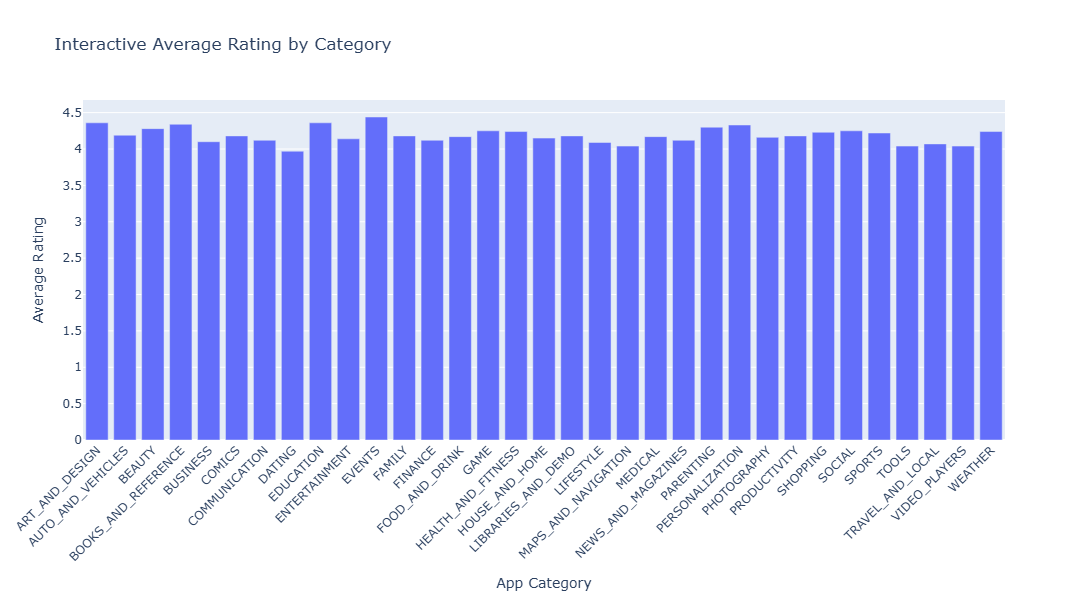

In [102]:
import plotly.express as px

fig = px.bar(
    plotly_rating_data,
    x="Category",
    y="Rating",
    title="Interactive Average Rating by Category",
    labels={
        "Category": "App Category",
        "Rating": "Average Rating"
    },
    hover_data=["Rating"]
)

fig.update_layout(
    xaxis_tickangle=-45,
    height=600
)

fig.show()

Observation: The interactive chart shows the average rating across the different app categories. It allows the ratings of all 33 categories to be explored interactively by hovering over the bars.

## 12.Conclusion

1)The app distribution shows that some categories have much larger representation than others. Family, Game, and Tools contain the highest number of    apps in the cleaned dataset, indicating a relatively high level of competition in these categories.

2)User ratings are generally high, with an average rating of 4.17. The rating distribution shows that most rated apps have ratings toward the higher    end of the scale, highlighting the importance of maintaining good app quality and user satisfaction.

3)Sentiment analysis shows that 68.01% of the analyzed reviews are positive, while 19.76% are negative and 12.23% are neutral. Category-level           sentiment varies, showing that developers can consider user feedback specific to their app category when planning improvements.

Overall, the analysis shows that category competition, app ratings, user sentiment, and pricing are useful factors to consider when planning a new app.